# Statistical Analysis

Two descriptive checks: revenue concentration and observed repeat-order intervals. Neither analysis establishes causality or a probability of permanent churn.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import seaborn as sns


def find_project_root():
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (candidate / "sql").exists() and (candidate / "python").exists():
            return candidate
    raise FileNotFoundError("Project root not found")


PROJECT_ROOT = find_project_root()
sys.path.append(str(PROJECT_ROOT / "python" / "src"))
IMAGES_DIR = PROJECT_ROOT / "images"

from db import get_engine
from sql_utils import read_sql_file

engine = get_engine()


# Same modern editorial theme used in the visualization notebook.
sns.set_theme(
    style="white",
    context="talk",
    font_scale=0.95,
    rc={
        "figure.facecolor": "#FCFBF8",
        "axes.facecolor": "#FCFBF8",
        "savefig.facecolor": "#FCFBF8",
        "axes.edgecolor": "#CFC8D3",
        "axes.labelcolor": "#2B2630",
        "axes.titlecolor": "#231F27",
        "axes.titleweight": "bold",
        "axes.titlesize": 16,
        "axes.labelsize": 11,
        "xtick.color": "#5F5866",
        "ytick.color": "#5F5866",
        "grid.color": "#E8E2EA",
        "grid.linewidth": 0.8,
        "grid.alpha": 0.85,
        "legend.frameon": False,
        "figure.dpi": 110,
        "savefig.bbox": "tight",
    },
)

BG = "#FCFBF8"
TEXT = "#2B2630"
SUBTEXT = "#6F6875"
GRID = "#E8E2EA"
VIOLET = "#6D5DFB"
VIOLET_LIGHT = "#D9D4FF"
CORAL = "#E76F51"
TEAL = "#2A9D8F"
NEUTRAL = "#AAA3AE"
NEUTRAL_DARK = "#77707D"


def finish_axis(ax, grid_axis="y"):
    ax.grid(False)
    ax.grid(axis=grid_axis, color=GRID, linewidth=0.8)
    sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)
    ax.spines["left"].set_color("#C9C2CE")
    ax.spines["bottom"].set_color("#C9C2CE")


def add_note(ax, text):
    ax.text(
        0, -0.16, text,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=9, color=SUBTEXT,
    )


def save(fig, filename):
    fig.savefig(IMAGES_DIR / filename, dpi=180, bbox_inches="tight", facecolor=BG)
    plt.show()


def gini(values):
    x = np.sort(np.asarray(values, dtype=float))
    n = len(x)
    cumulative = np.cumsum(x)
    return (2 * np.sum(np.arange(1, n + 1) * x) - (n + 1) * cumulative[-1]) / (n * cumulative[-1])


## Revenue concentration

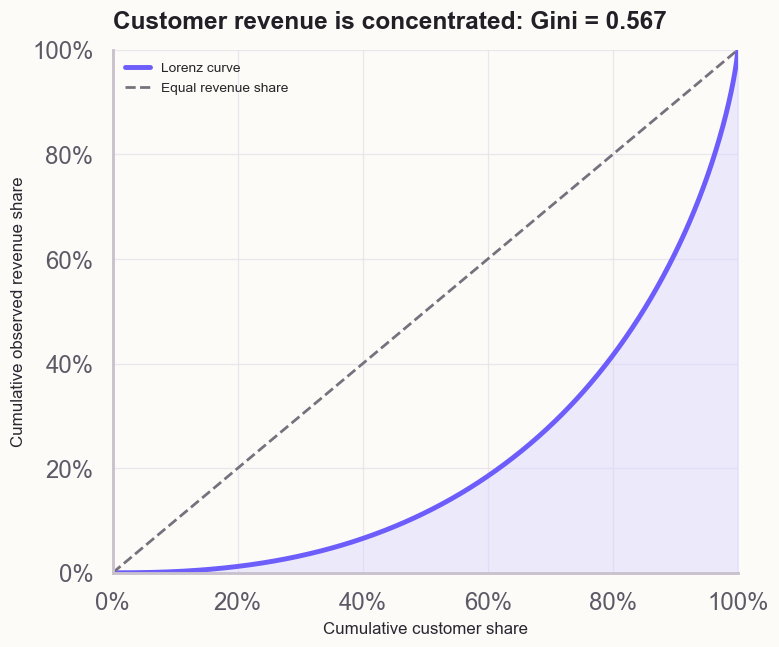

Gini coefficient: 0.567


In [4]:
ltv = read_sql_file(engine, "marts/03_customer_lifetime_revenue.sql")

x = np.sort(ltv["lifetime_revenue_usd"].to_numpy(float))
gini_score = gini(x)

cum_revenue = np.cumsum(x) / x.sum()
cum_customers = np.arange(1, len(x) + 1) / len(x)
lorenz_x = np.r_[0, cum_customers]
lorenz_y = np.r_[0, cum_revenue]

fig, ax = plt.subplots(figsize=(7.4, 6.2))

ax.plot(
    lorenz_x, lorenz_y,
    color=VIOLET, linewidth=3.2,
    label="Lorenz curve",
)
ax.fill_between(lorenz_x, lorenz_y, color=VIOLET_LIGHT, alpha=0.45)
ax.plot(
    [0, 1], [0, 1],
    color=NEUTRAL_DARK, linewidth=1.8, linestyle="--",
    label="Equal revenue share",
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

ax.set_title(
    f"Customer revenue is concentrated: Gini = {gini_score:.3f}",
    loc="left", pad=14,
)
ax.set_xlabel("Cumulative customer share")
ax.set_ylabel("Cumulative observed revenue share")

finish_axis(ax, grid_axis="both")
ax.legend(loc="upper left", fontsize=9, handlelength=1.8, labelspacing=0.5)
fig.tight_layout()
save(fig, "gini_lorenz_curve.png")

print(f"Gini coefficient: {gini_score:.3f}")

## Observed repeat-order intervals

A purchase gap exists only when a customer later places another observed order. The distribution therefore describes repeat purchasers and **does not estimate** `P(customer never returns | inactivity duration)`.

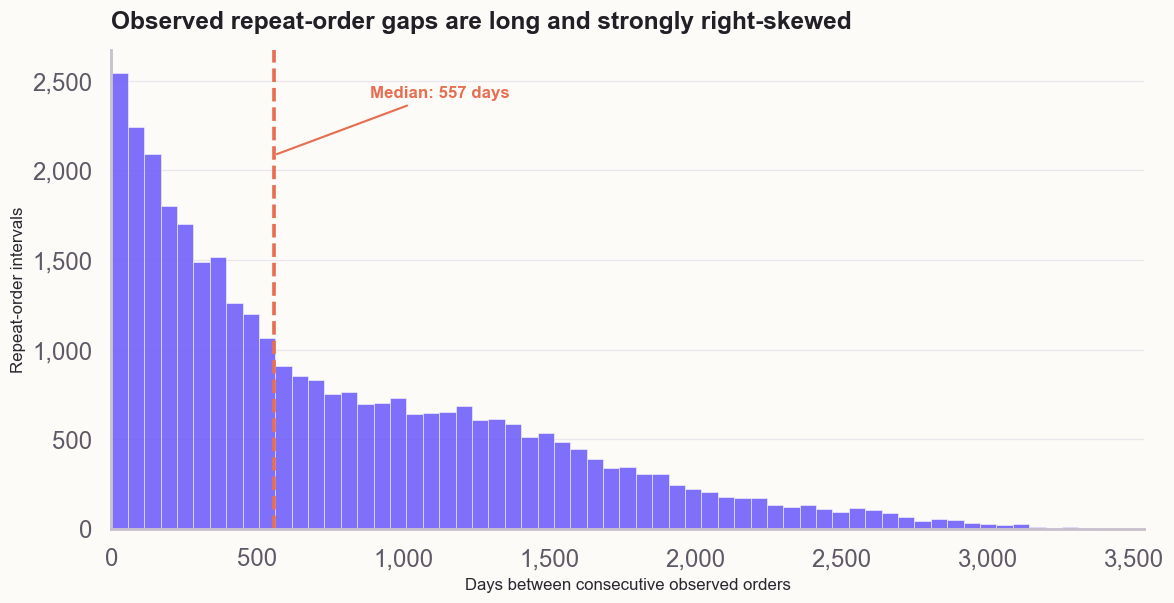

0.25     216.0
0.50     557.0
0.75    1193.0
Name: gap_days, dtype: float64
Observed repeat-order intervals: 33,643


In [3]:
intervals = read_sql_file(engine, "marts/08_repeat_purchase_intervals.sql")

gaps = intervals["gap_days"].astype(int)
q = gaps.quantile([0.25, 0.50, 0.75])
median_gap = int(q.loc[0.50])

fig, ax = plt.subplots(figsize=(11, 5.8))

sns.histplot(
    data=gaps,
    bins=60,
    color=VIOLET,
    edgecolor=BG,
    linewidth=0.35,
    alpha=0.88,
    ax=ax,
)

ax.axvline(
    median_gap,
    color=CORAL,
    linewidth=2.4,
    linestyle="--",
)

ax.annotate(
    f"Median: {median_gap:,} days",
    xy=(median_gap, ax.get_ylim()[1] * 0.78),
    xytext=(median_gap + 330, ax.get_ylim()[1] * 0.90),
    arrowprops=dict(arrowstyle="-", color=CORAL, linewidth=1.4),
    color=CORAL,
    fontsize=11,
    fontweight="bold",
)

ax.set_title(
    "Observed repeat-order gaps are long and strongly right-skewed",
    loc="left", pad=14,
)
ax.set_xlabel("Days between consecutive observed orders")
ax.set_ylabel("Repeat-order intervals")
ax.set_xlim(left=0)
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

finish_axis(ax, grid_axis="y")
fig.tight_layout()
save(fig, "purchase_gap_distribution.png")

print(q)
print(f"Observed repeat-order intervals: {len(gaps):,}")